In [8]:
import os
import pickle
import pyreadr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import jax
import jax.numpy as jnp
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.bijectors as tfb

# Optional: Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [9]:
# ========
# 1. SETUP
# ========
param_names = ["Canon", "Sony", "Nikon", "Panasonic", "Pixels", "Zoom", "Video", "Swivel", "Wifi", "Price"]
k_dim = len(param_names)

In [13]:
# ===============
# 2. LOAD SAMPLES
# ===============
liesel_path = "./Data/liesel_posterior_samples_camera.pkl"
bayesm_path = "./Data/bayesm_output_camera.RData"

print(f"Loading Liesel samples from {liesel_path}")
with open(liesel_path, "rb") as f:
    liesel_data = pickle.load(f)
liesel_samples = liesel_data["samples"]

print(f"Loading Bayesm samples from {bayesm_path}")
bayesm_rdata = pyreadr.read_r(bayesm_path)

Loading Liesel samples from ./Data/liesel_posterior_samples_camera.pkl
Loading Bayesm samples from ./Data/bayesm_output_camera.RData


In [14]:
# ==============================
# 3. DATA PROCESSING & RESHAPING
# ==============================
print("Standardizing array shapes for comparison...")

# --- Prepare Liesel Arrays ---
# Mu: Flatten chains/draws to (Total_Draws, Params)
liesel_mu = liesel_samples["mu"].reshape(-1, k_dim)

# Beta: Flatten chains/draws to (Total_Draws, Units, Params)
liesel_beta_raw = liesel_samples["beta_i"]
if liesel_beta_raw.ndim == 4:
    n_chains, n_draws, n_units, _ = liesel_beta_raw.shape
    liesel_beta_full = liesel_beta_raw.reshape(n_chains * n_draws, n_units, k_dim)
else:
    liesel_beta_full = liesel_beta_raw
    n_units = liesel_beta_full.shape[1]

# --- Prepare Bayesm Arrays ---
# Mu
bayesm_mu = bayesm_rdata["mu_draws_df"].values
n_bayesm_draws = bayesm_mu.shape[0]

# Beta: Reshape Fortran-ordered dataframe back to (Draws, Units, Params)
bayesm_beta_df = bayesm_rdata['beta_reordered']
n_samples_r = bayesm_beta_df.size // (n_units * k_dim)
bayesm_beta_full = bayesm_beta_df.values.reshape((n_units, n_samples_r, k_dim), order='F').transpose(1, 0, 2)

print(f"Liesel Shapes -> Mu: {liesel_mu.shape}, Beta: {liesel_beta_full.shape}")
print(f"Bayesm Shapes -> Mu: {bayesm_mu.shape}, Beta: {bayesm_beta_full.shape}")

# Ensure exact match in units before plotting
assert liesel_beta_full.shape[1] == bayesm_beta_full.shape[1], f"Unit mismatch! Liesel: {liesel_beta_full.shape[1]}, Bayesm: {bayesm_beta_full.shape[1]}"

Standardizing array shapes for comparison...
Liesel Shapes -> Mu: (10000, 10), Beta: (10000, 332, 10)
Bayesm Shapes -> Mu: (9250, 10), Beta: (9250, 332, 10)



=== Global Parameters (Baseline Means) Summary Table ===


,Parameter,Bayesm_Mean,Liesel_Mean,Diff_Mean,Bayesm_Std,Liesel_Std
0,Canon,1.9571,2.0077,-0.0506,0.3461,0.3671
1,Sony,1.5432,1.5774,-0.0343,0.3602,0.3823
2,Nikon,1.6588,1.7033,-0.0444,0.3559,0.3731
3,Panasonic,1.1603,1.1760,-0.0156,0.3565,0.3721
4,Pixels,1.3713,1.4323,-0.0610,0.1321,0.1385
5,Zoom,1.6845,1.7572,-0.0728,0.1326,0.1396
6,Video,1.2788,1.3334,-0.0546,0.1095,0.1138
7,Swivel,0.7360,0.7675,-0.0315,0.1060,0.1098
8,Wifi,1.1625,1.2103,-0.0478,0.1149,0.1218
9,Price,-3.4558,-3.5869,0.1312,0.1725,0.1820


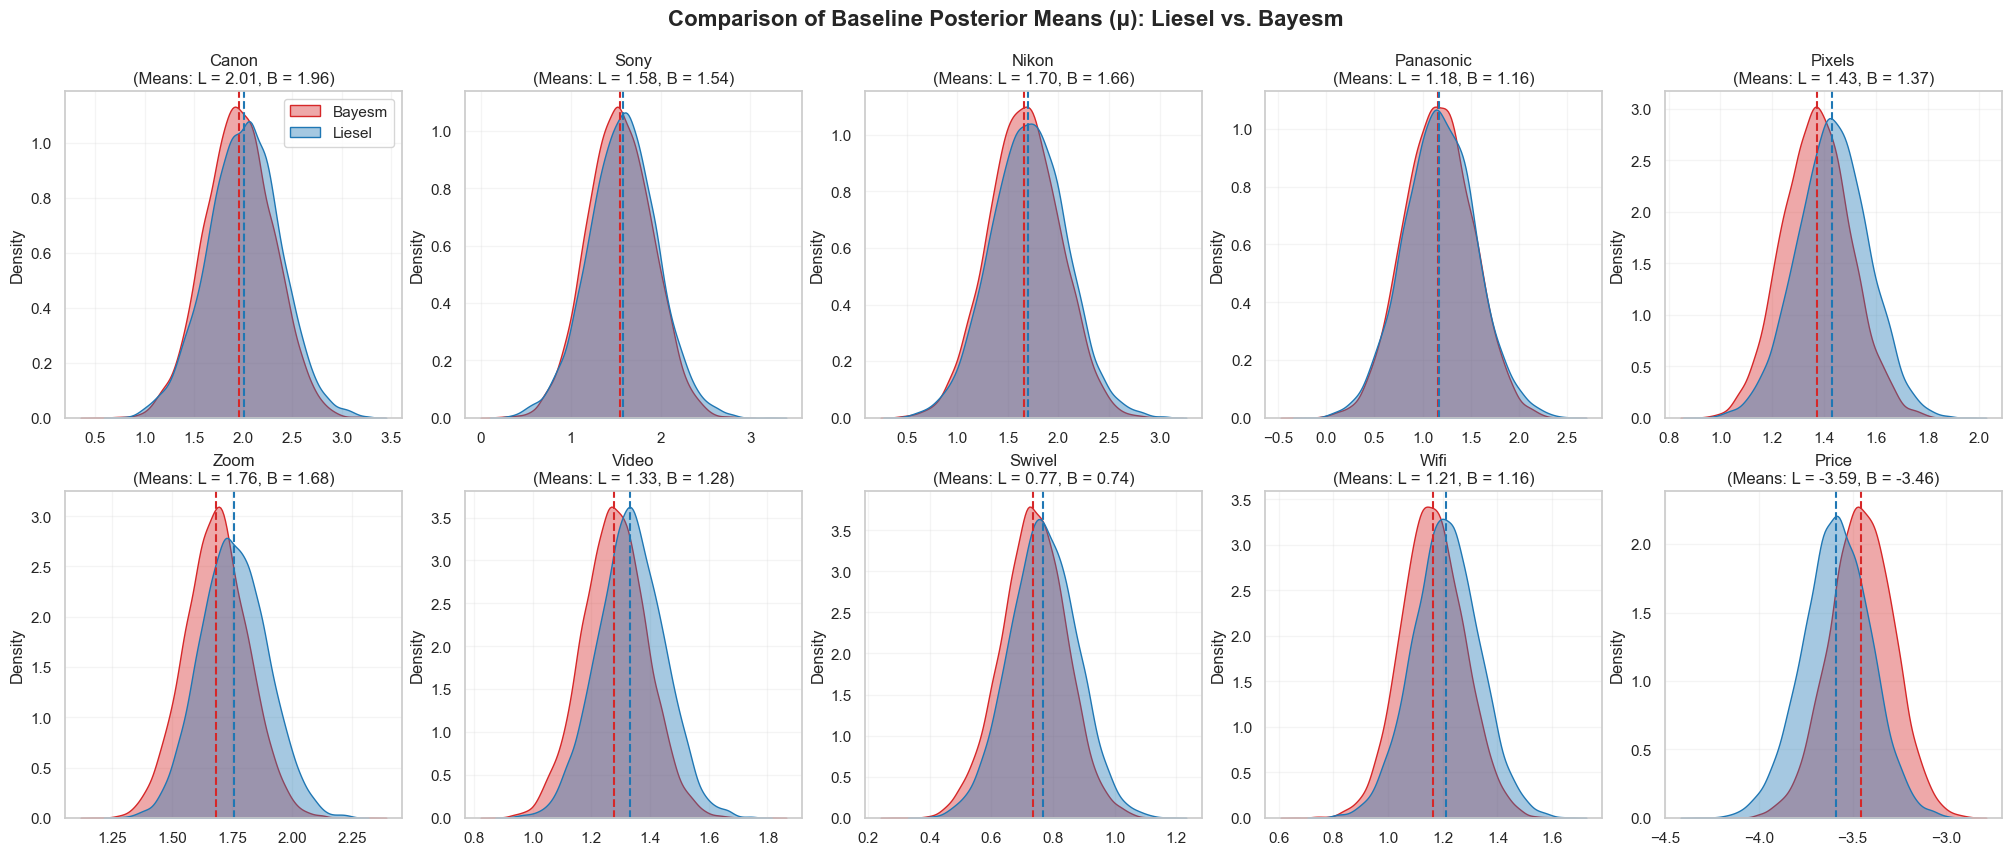

In [15]:
# ============================================
# 4. GLOBAL PARAMETERS: BASELINE MEANS
# ============================================

def create_summary_table(r_mu, l_mu, p_names):
    return pd.DataFrame({
        'Parameter': p_names,
        'Bayesm_Mean': r_mu.mean(axis=0),
        'Liesel_Mean': l_mu.mean(axis=0),
        'Diff_Mean': r_mu.mean(axis=0) - l_mu.mean(axis=0),
        'Bayesm_Std': r_mu.std(axis=0),
        'Liesel_Std': l_mu.std(axis=0)
    }).round(4)

print("\n=== Global Parameters (Baseline Means) Summary Table ===")
display(create_summary_table(bayesm_mu, liesel_mu, param_names))

# --- KDE Plots for Baseline Means ---
fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
for i, (ax, param) in enumerate(zip(axes.flatten(), param_names)):
    # Plot Bayesm FIRST so it goes to the back
    sns.kdeplot(bayesm_mu[:, i], ax=ax, fill=True, color="#d62728", alpha=0.4, label="Bayesm")
    # Plot Liesel SECOND so it goes in front
    sns.kdeplot(liesel_mu[:, i], ax=ax, fill=True, color="#1f77b4", alpha=0.4, label="Liesel")
    
    ax.axvline(np.mean(bayesm_mu[:, i]), color="#d62728", linestyle="--")
    ax.axvline(np.mean(liesel_mu[:, i]), color="#1f77b4", linestyle="--")
    ax.set_title(f"{param}\n(Means: L = {np.mean(liesel_mu[:, i]):.2f}, B = {np.mean(bayesm_mu[:, i]):.2f})")
    ax.grid(True, alpha=0.2)
    if i == 0: ax.legend(loc="upper right")

plt.suptitle("Comparison of Baseline Posterior Means (\u03bc): Liesel vs. Bayesm", y=1.05, fontsize=16, fontweight='bold')
plt.show()

In [16]:
# ====================================
# 5. COVARIANCE AND CORRELATION TABLES
# ====================================

def format_cov_corr_table(std_draws, corr_draws, p_names):
    std_mean, std_sd = np.mean(std_draws, axis=0), np.std(std_draws, axis=0)
    corr_mean, corr_sd = np.mean(corr_draws, axis=0), np.std(corr_draws, axis=0)
    
    df = pd.DataFrame(index=p_names, columns=p_names)
    for i in range(len(p_names)):
        for j in range(len(p_names)):
            if i == j: df.iloc[i, j] = f"{std_mean[i]:.2f} ({std_sd[i]:.2f})"
            elif j > i: df.iloc[i, j] = f"{corr_mean[i, j]:.2f} ({corr_sd[i, j]:.2f})"
            else: df.iloc[i, j] = ""
    return df

def format_cov_corr_diff_table(b_stds, l_stds, b_corrs, l_corrs, p_names):
    """Calculates Bayesm - Liesel differences for SDs and Correlations."""
    b_std_m, b_std_sd = np.mean(b_stds, axis=0), np.std(b_stds, axis=0)
    l_std_m, l_std_sd = np.mean(l_stds, axis=0), np.std(l_stds, axis=0)
    
    b_corr_m, b_corr_sd = np.mean(b_corrs, axis=0), np.std(b_corrs, axis=0)
    l_corr_m, l_corr_sd = np.mean(l_corrs, axis=0), np.std(l_corrs, axis=0)
    
    diff_std_m = b_std_m - l_std_m
    diff_std_sd = b_std_sd - l_std_sd
    diff_corr_m = b_corr_m - l_corr_m
    diff_corr_sd = b_corr_sd - l_corr_sd
    
    df = pd.DataFrame(index=p_names, columns=p_names)
    for i in range(len(p_names)):
        for j in range(len(p_names)):
            if i == j: 
                df.iloc[i, j] = f"{diff_std_m[i]:.3f} ({diff_std_sd[i]:.3f})"
            elif j > i: 
                df.iloc[i, j] = f"{diff_corr_m[i, j]:.3f} ({diff_corr_sd[i, j]:.3f})"
            else: 
                df.iloc[i, j] = ""
    return df

# Liesel Covariance logic
latent_samples = liesel_samples["sigma_inv_chol_latent"].reshape(-1, int(k_dim * (k_dim + 1) / 2))
bijector = tfb.FillScaleTriL()
v_latent_to_cov = jax.vmap(lambda v: jnp.linalg.inv(bijector.forward(v) @ bijector.forward(v).T))
liesel_cov_draws = np.array(v_latent_to_cov(latent_samples))
l_stds = np.sqrt(np.diagonal(liesel_cov_draws, axis1=1, axis2=2))
l_corrs = liesel_cov_draws / (l_stds[:, :, None] * l_stds[:, None, :])

# Bayesm Covariance logic
if 'cov_draws_df' in bayesm_rdata:
    bayesm_cov_draws = bayesm_rdata['cov_draws_df'].values.reshape((-1, k_dim, k_dim), order='C').transpose((0, 2, 1))
    b_stds = np.sqrt(np.diagonal(bayesm_cov_draws, axis1=1, axis2=2))
    b_corrs = bayesm_cov_draws / (b_stds[:, :, None] * b_stds[:, None, :])

    print("\n=== Correlations and standard deviations of betas (Liesel) ===")
    display(format_cov_corr_table(l_stds, l_corrs, param_names))
    print("\n=== Correlations and standard deviations of betas (Bayesm) ===")
    display(format_cov_corr_table(b_stds, b_corrs, param_names))
    print("\n=== DIFFERENCE in Corrs and SDs (Bayesm - Liesel) ===")
    display(format_cov_corr_diff_table(b_stds, l_stds, b_corrs, l_corrs, param_names))
else:
    print("\n[WARNING]: 'cov_draws_df' was not found. Please export it from R.")


=== Correlations and standard deviations of betas (Liesel) ===


,Canon,Sony,Nikon,Panasonic,Pixels,Zoom,Video,Swivel,Wifi,Price
Canon,5.76 (0.35),0.96 (0.01),0.97 (0.01),0.96 (0.01),-0.58 (0.06),-0.50 (0.07),-0.28 (0.09),-0.19 (0.09),-0.29 (0.08),-0.60 (0.05)
Sony,,6.03 (0.36),0.96 (0.01),0.98 (0.01),-0.52 (0.06),-0.49 (0.07),-0.28 (0.09),-0.17 (0.09),-0.24 (0.08),-0.61 (0.05)
Nikon,,,5.95 (0.35),0.96 (0.01),-0.56 (0.06),-0.54 (0.06),-0.29 (0.09),-0.19 (0.09),-0.27 (0.08),-0.58 (0.05)
Panasonic,,,,5.92 (0.35),-0.53 (0.06),-0.48 (0.07),-0.24 (0.09),-0.20 (0.09),-0.24 (0.08),-0.61 (0.05)
Pixels,,,,,1.96 (0.13),0.41 (0.07),0.09 (0.09),0.03 (0.09),-0.04 (0.09),0.39 (0.07)
Zoom,,,,,,1.94 (0.13),0.08 (0.09),-0.05 (0.09),0.17 (0.09),0.20 (0.08)
Video,,,,,,,1.40 (0.11),0.16 (0.09),0.11 (0.10),0.08 (0.09)
Swivel,,,,,,,,1.45 (0.11),0.14 (0.10),0.09 (0.09)
Wifi,,,,,,,,,1.60 (0.12),0.04 (0.09)
Price,,,,,,,,,,2.60 (0.16)



=== Correlations and standard deviations of betas (Bayesm) ===


,Canon,Sony,Nikon,Panasonic,Pixels,Zoom,Video,Swivel,Wifi,Price
Canon,11.16 (0.66),0.76 (0.03),0.51 (0.05),0.42 (0.04),-0.10 (0.02),-0.05 (0.02),-0.01 (0.02),-0.02 (0.02),-0.02 (0.02),-0.13 (0.01)
Sony,,1.97 (0.16),0.29 (0.09),0.45 (0.07),0.06 (0.09),0.00 (0.09),0.01 (0.08),0.05 (0.07),0.13 (0.08),-0.16 (0.09)
Nikon,,,1.40 (0.12),0.04 (0.11),-0.07 (0.12),-0.28 (0.11),-0.09 (0.10),-0.05 (0.10),-0.07 (0.11),0.13 (0.13)
Panasonic,,,,1.19 (0.11),0.01 (0.16),0.13 (0.15),0.20 (0.13),-0.12 (0.12),0.11 (0.14),-0.07 (0.17)
Pixels,,,,,1.56 (0.13),0.13 (0.10),-0.10 (0.09),-0.12 (0.09),-0.29 (0.09),0.13 (0.11)
Zoom,,,,,,1.52 (0.12),-0.08 (0.10),-0.14 (0.09),0.09 (0.10),-0.17 (0.10)
Video,,,,,,,1.23 (0.12),0.12 (0.11),-0.00 (0.14),-0.18 (0.14)
Swivel,,,,,,,,1.28 (0.10),0.08 (0.12),-0.04 (0.13)
Wifi,,,,,,,,,1.31 (0.12),-0.15 (0.13)
Price,,,,,,,,,,1.81 (0.12)



=== DIFFERENCE in Corrs and SDs (Bayesm - Liesel) ===


,Canon,Sony,Nikon,Panasonic,Pixels,Zoom,Video,Swivel,Wifi,Price
Canon,5.396 (0.310),-0.201 (0.025),-0.458 (0.046),-0.546 (0.033),0.479 (-0.039),0.451 (-0.046),0.269 (-0.066),0.172 (-0.067),0.269 (-0.059),0.464 (-0.036)
Sony,,-4.066 (-0.192),-0.673 (0.082),-0.525 (0.067),0.588 (0.025),0.498 (0.021),0.290 (-0.011),0.222 (-0.014),0.372 (-0.006),0.446 (0.041)
Nikon,,,-4.541 (-0.237),-0.915 (0.106),0.491 (0.061),0.258 (0.046),0.201 (0.016),0.141 (0.014),0.206 (0.029),0.704 (0.077)
Panasonic,,,,-4.730 (-0.232),0.546 (0.095),0.610 (0.087),0.436 (0.037),0.087 (0.039),0.354 (0.058),0.532 (0.123)
Pixels,,,,,-0.390 (-0.008),-0.284 (0.025),-0.193 (-0.001),-0.156 (-0.002),-0.257 (-0.003),-0.252 (0.036)
Zoom,,,,,,-0.420 (-0.011),-0.155 (0.003),-0.087 (-0.001),-0.079 (0.008),-0.376 (0.025)
Video,,,,,,,-0.167 (0.004),-0.035 (0.018),-0.109 (0.036),-0.252 (0.050)
Swivel,,,,,,,,-0.178 (-0.013),-0.057 (0.023),-0.129 (0.041)
Wifi,,,,,,,,,-0.290 (0.002),-0.190 (0.046)
Price,,,,,,,,,,-0.785 (-0.046)


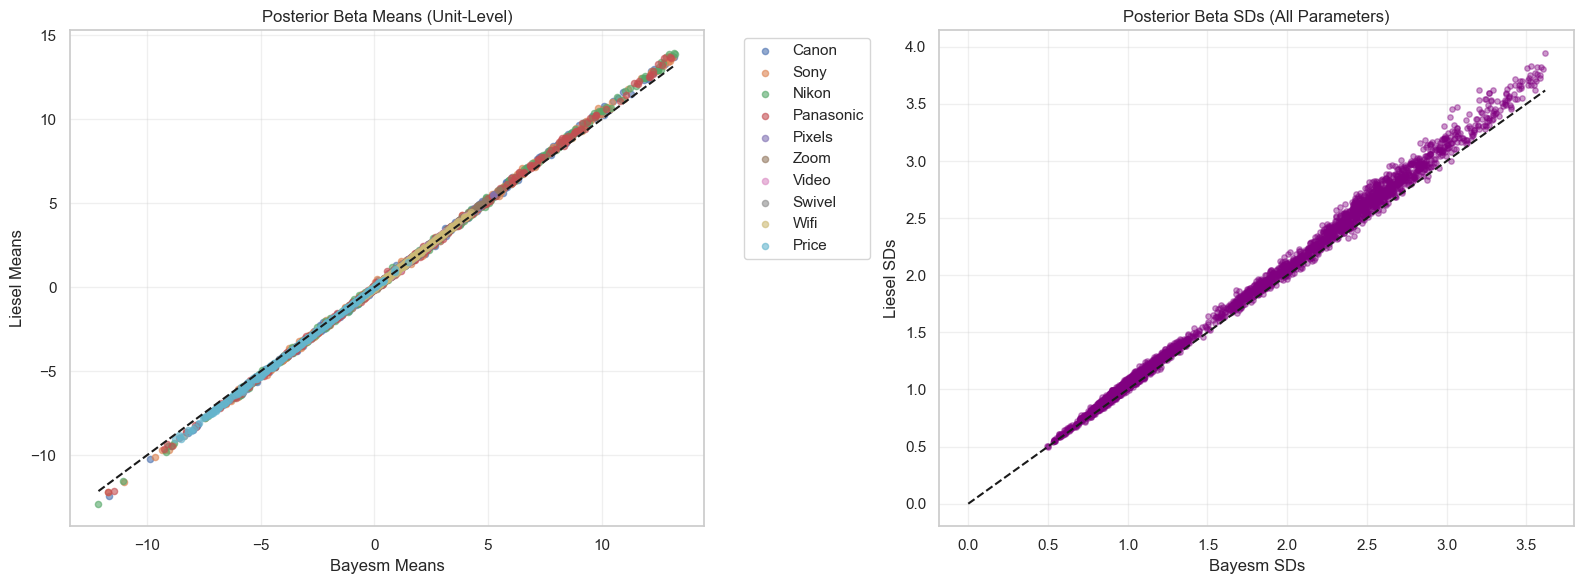

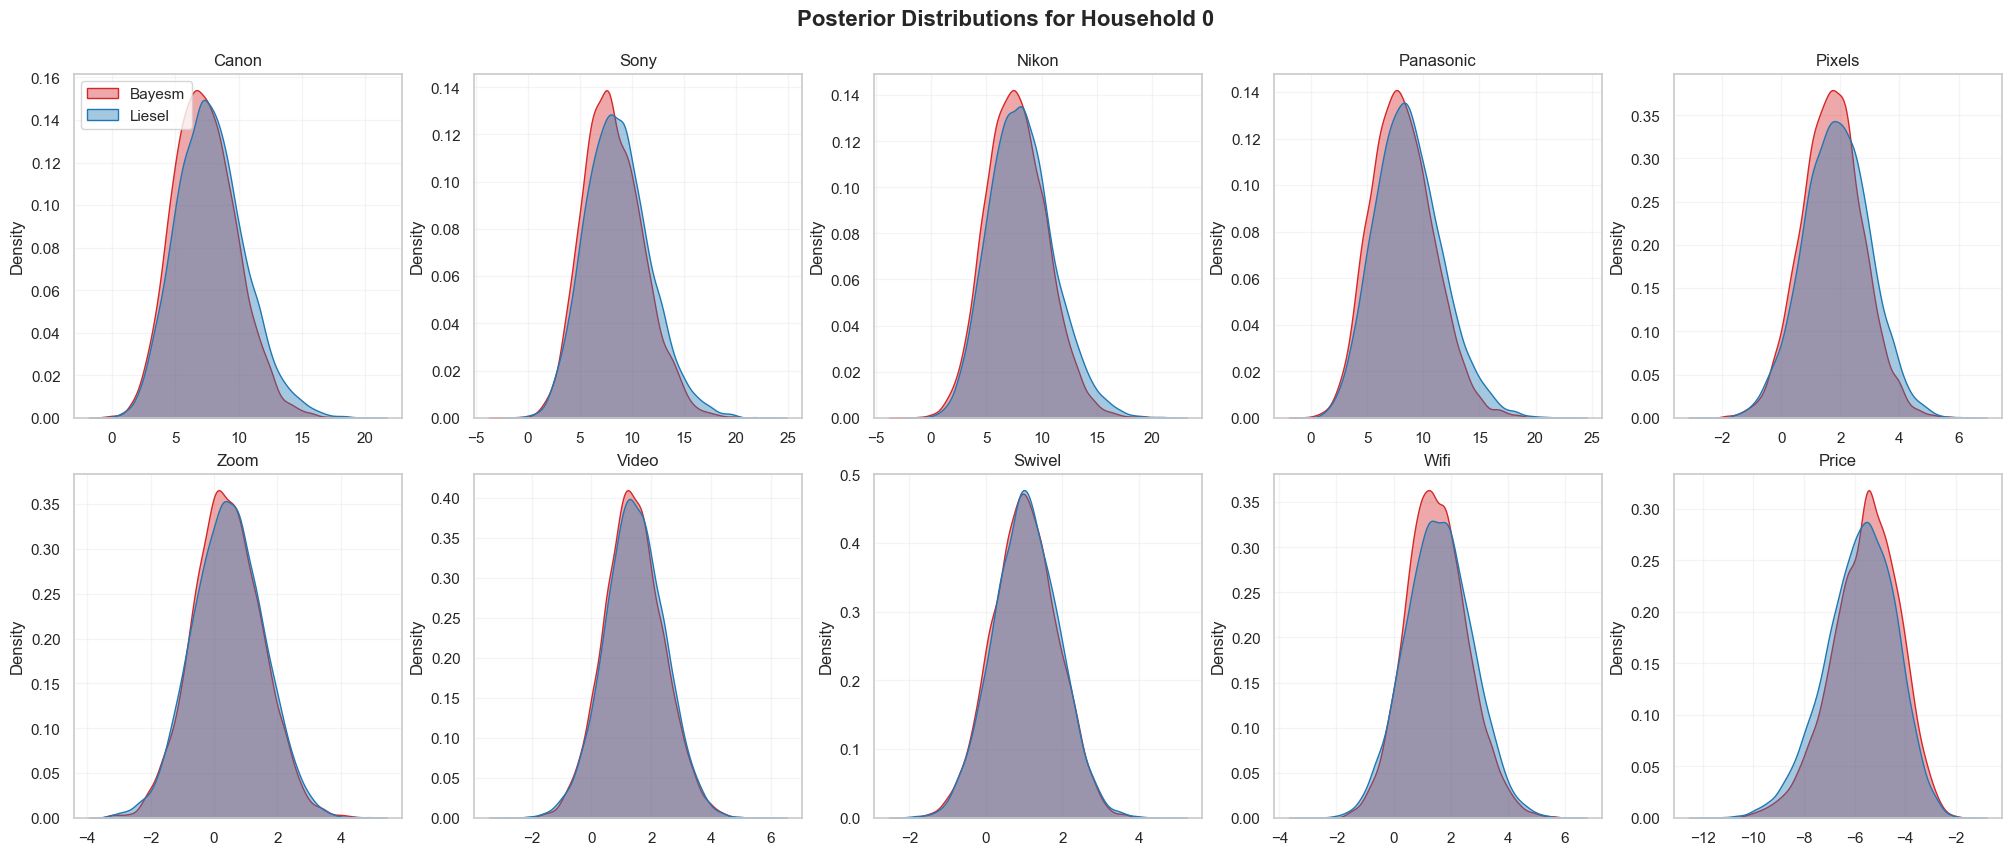

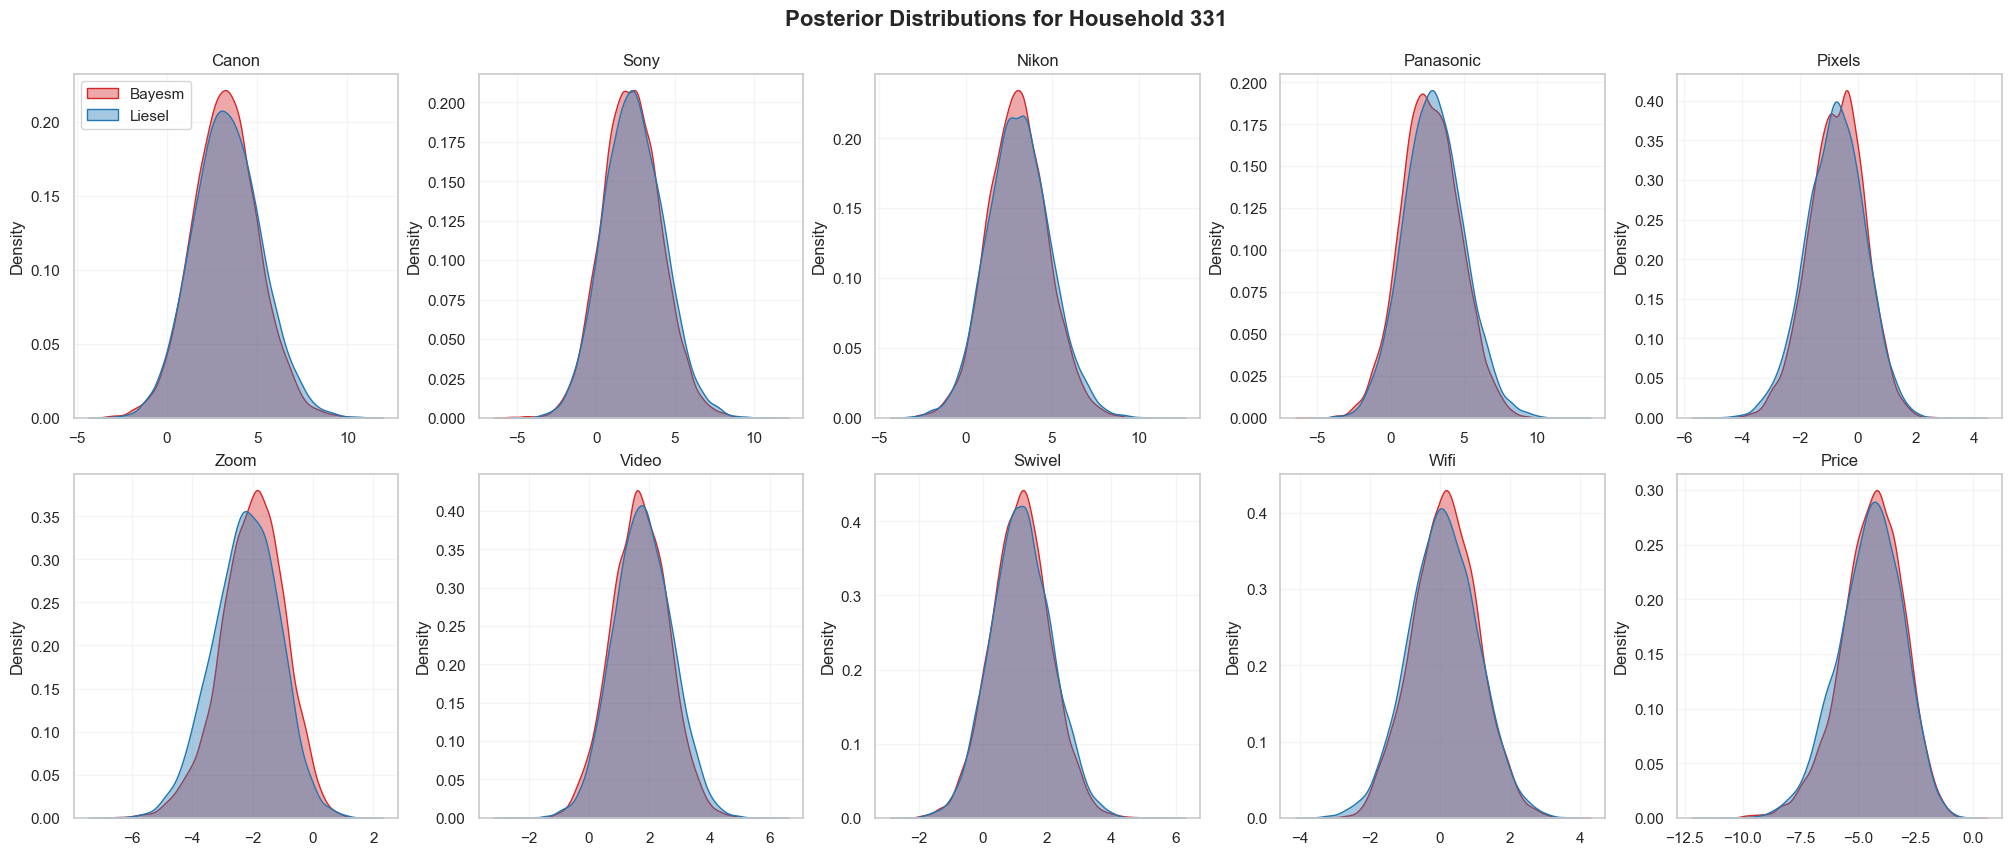

In [17]:
# ==================================
# 6. HOUSEHOLD HETEROGENEITY (BETAS)
# ==================================

# --- Parameter Recovery (Scatter Means & SDs) ---
r_beta_means = np.mean(bayesm_beta_full, axis=0)
l_beta_means = np.mean(liesel_beta_full, axis=0)

r_beta_sds = np.std(bayesm_beta_full, axis=0).flatten()
l_beta_sds = np.std(liesel_beta_full, axis=0).flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean Scatter
for i, param in enumerate(param_names):
    axes[0].scatter(r_beta_means[:, i], l_beta_means[:, i], alpha=0.6, s=20, label=param)
axes[0].plot([r_beta_means.min(), r_beta_means.max()], [r_beta_means.min(), r_beta_means.max()], 'k--')
axes[0].set(title="Posterior Beta Means (Unit-Level)", xlabel="Bayesm Means", ylabel="Liesel Means")
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# SD Scatter
axes[1].scatter(r_beta_sds, l_beta_sds, alpha=0.4, color='purple', s=15)
axes[1].plot([0, r_beta_sds.max()], [0, r_beta_sds.max()], 'k--')
axes[1].set(title="Posterior Beta SDs (All Parameters)", xlabel="Bayesm SDs", ylabel="Liesel SDs")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Pooled vs Individual Distributions Plotter ---
def plot_beta_distributions(r_data, l_data, param_names, title_prefix, is_pooled=False, color_l="#1f77b4", color_r="#d62728"):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)
    for i, (ax, param) in enumerate(zip(axes.flatten(), param_names)):
        r_vals = r_data[:, i] if is_pooled else r_data[:, i]
        l_vals = l_data[:, i] if is_pooled else l_data[:, i]
        
        # Plot Bayesm FIRST so it goes to the back
        sns.kdeplot(r_vals, ax=ax, fill=True, color=color_r, alpha=0.4, label="Bayesm")
        # Plot Liesel SECOND so it goes in front
        sns.kdeplot(l_vals, ax=ax, fill=True, color=color_l, alpha=0.4, label="Liesel")
        
        ax.set_title(param, fontsize=12)
        ax.grid(True, alpha=0.2)
        if i == 0: ax.legend(loc="upper left")
        
    plt.suptitle(title_prefix, y=1.05, fontsize=16, fontweight='bold')
    plt.show()

# Individual Unit Plots (Unit 0 and Unit 331)
plot_beta_distributions(bayesm_beta_full[:, 0, :], liesel_beta_full[:, 0, :], param_names, "Posterior Distributions for Household 0")
plot_beta_distributions(bayesm_beta_full[:, -1, :], liesel_beta_full[:, -1, :], param_names, f"Posterior Distributions for Household {n_units-1}")

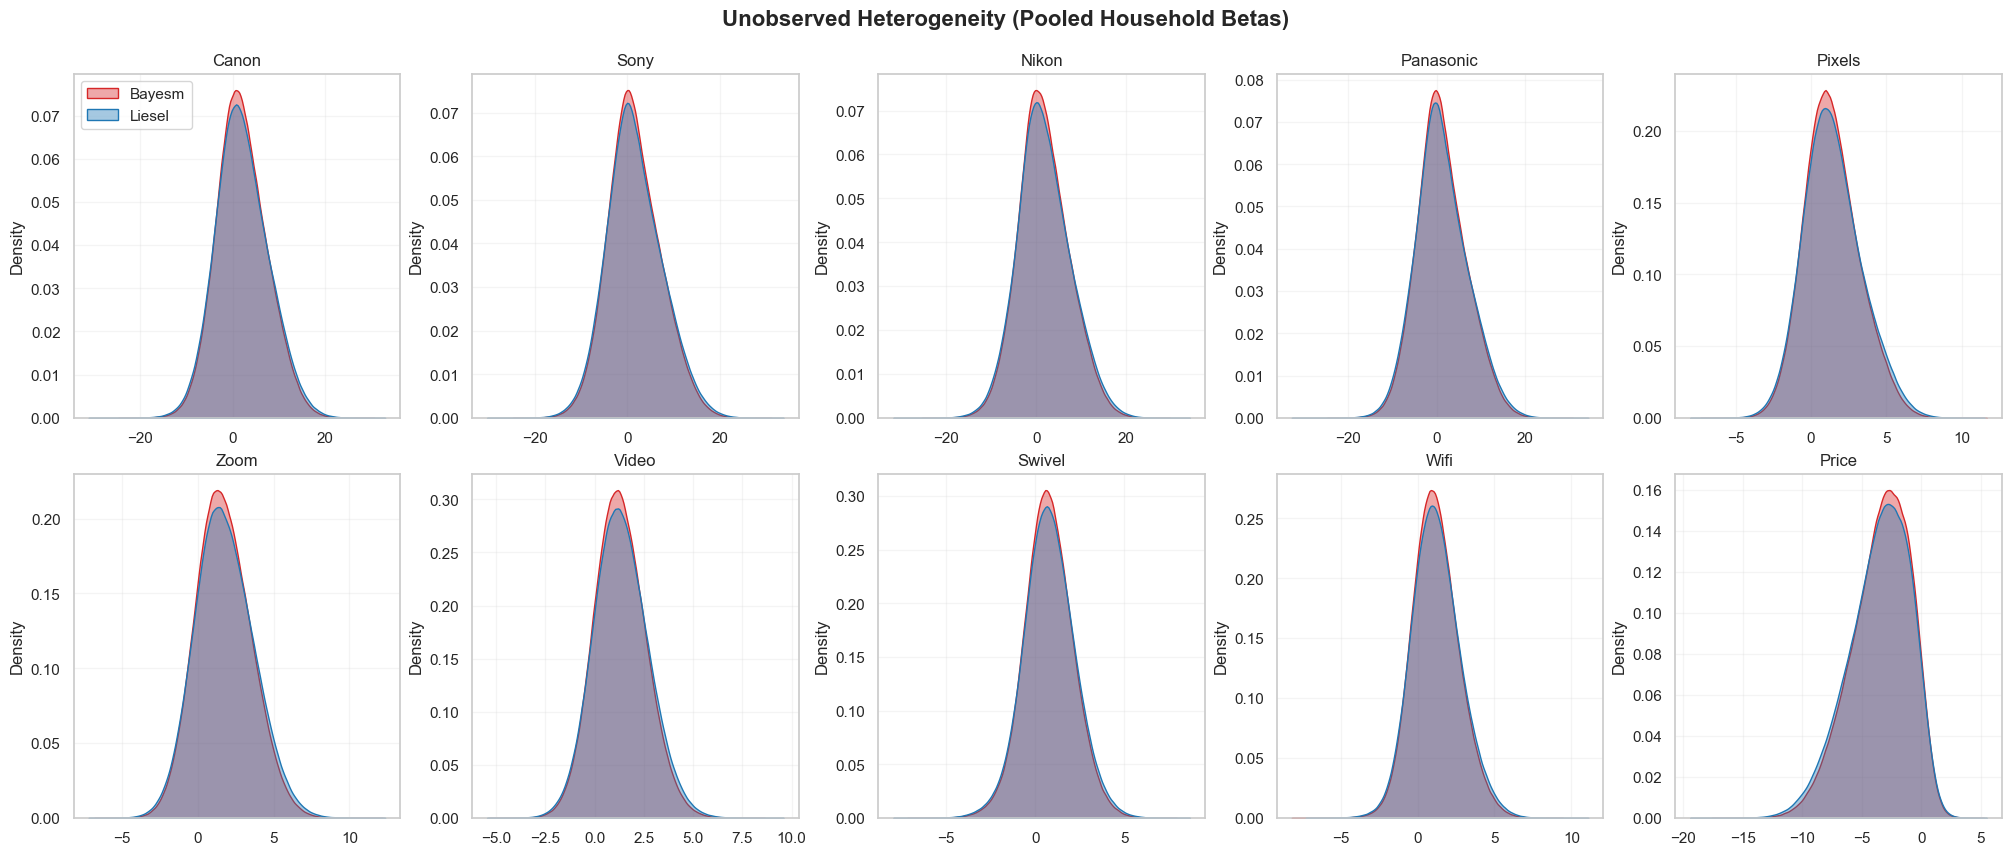

In [ ]:
# Pooled Plot
# (Note: This combines thousands of draws across 332 units, so it takes 8/9 minutes to compute the KDE)
plot_beta_distributions(
    bayesm_beta_full.reshape(-1, k_dim), 
    liesel_beta_full.reshape(-1, k_dim), 
    param_names, 
    "Unobserved Heterogeneity (Pooled Household Betas)", 
    is_pooled=True
)